# Linear Regression

คุณได้รับงานเป็นที่ปรึกษาบริษัท E-Commerce ขายเสื้อผ้าแห่งหนึ่ง  
บริษัทนี้มี **แอปมือถือ** และ **เว็บไซต์** ให้ลูกค้าซื้อเสื้อผ้าออนไลน์ แต่ก็มีหน้าร้านให้ลูกค้าได้ลองเสื้อผ้าและมีผู้ให้คำแนะนำด้านแฟชันส่วนตัว จากนั้นลูกค้าสามารถกลับบ้านและสั่งซื้อของจากทางเว็บไซต์หรือแอปมือถือก็ได้

ทางบริษัทกำลังลังเลว่าจะลงทุนกับพัฒนาเว็บไซต์หรือแอปมือถือดี
พวกเขาได้จ้างคุณมาเป็นที่ปรึกษาเพื่อตอบคำถามนี้

## Imports


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

## The Data
### Features
* Avg. Session Length: เวลาเฉลี่ยที่ลูกค้าใช้ที่หน้าร้าน ในหน่วยนาที
* Time on App: เวลาเฉลี่ยที่ลูกค้าใช้ในแอปมือถือ ในหน่วยนาที
* Time on Website: เวลาเฉลี่ยที่ลูกค้าใช้ในเว็บไซต์ ในหน่วยนาที
* Length of Membership: ระยะเวลาในหน่วยปีที่ลูกค้าเป็นสมาชิก

### Target
* Yearly Amount Spent: ยอดใช้จ่ายเฉลี่ยต่อปี

In [2]:
df = pd.read_csv('data/Ecommerce Customers.csv')

**ใช้ head() descibe() info() เพื่อดูข้อมูลเบื้องต้น**

In [3]:
df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']].head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [4]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


## Exploratory Data Analysis

วิเคราะห์ข้อมูลเบื่องต้น

**วาด [jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html) โดยให้แกน x เป็น `Time on Website` และ y เป็น `Yearly Amount Spent`**

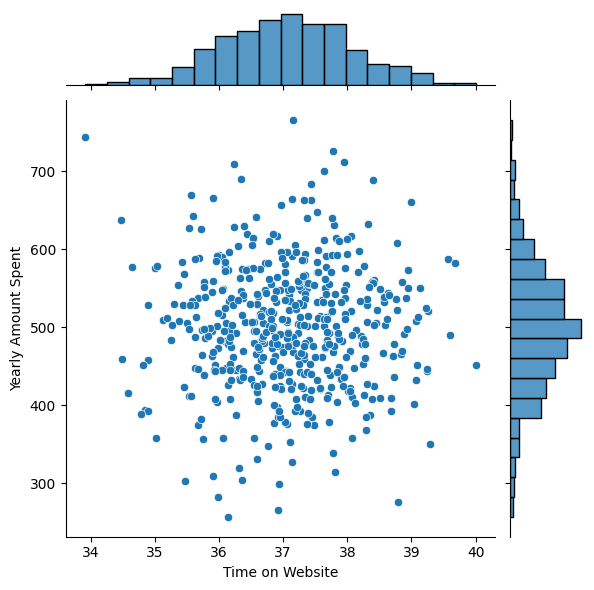

In [6]:
sns.jointplot(data=df, x="Time on Website", y="Yearly Amount Spent")

**วาด [jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html) โดยให้แกน x เป็น `Time on App` และแกน y เป็น `Yearly Amount Spent`**

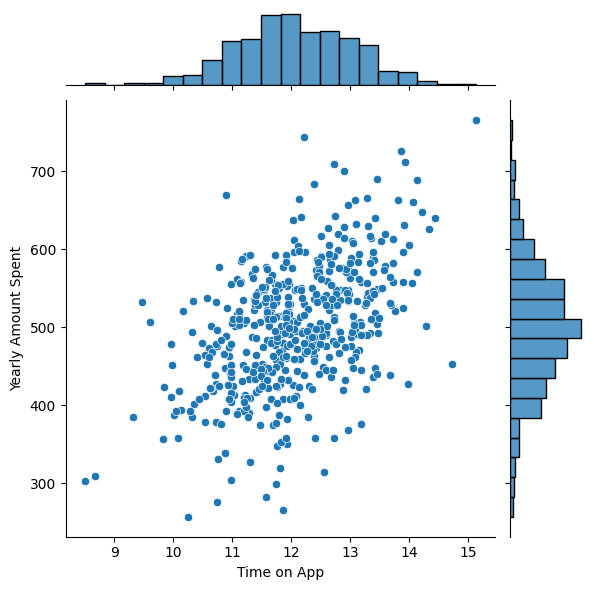

In [7]:
sns.jointplot(data=df, x="Time on App", y="Yearly Amount Spent")

**วาด [jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html) โดยให้แกน x เป็น `Avg. Session Length` และแกน y เป็น `Yearly Amount Spent`**

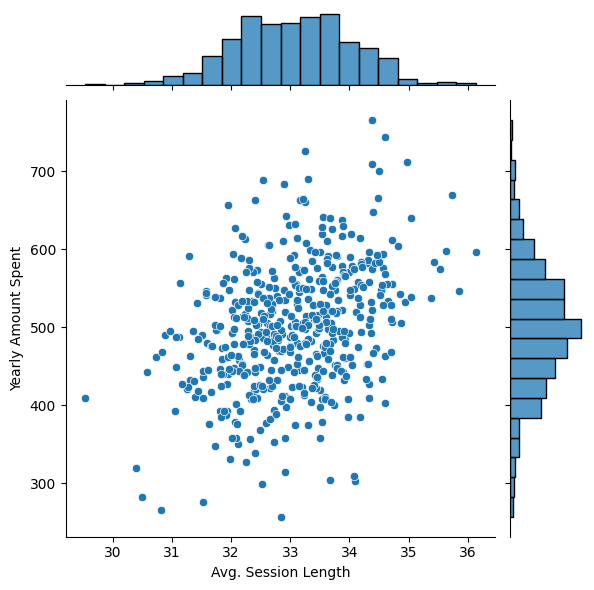

In [8]:
sns.jointplot(data=df, x="Avg. Session Length", y="Yearly Amount Spent")

**วาด [jointplot](https://seaborn.pydata.org/generated/seaborn.jointplot.html) โดยให้แกน x เป็น `Length of Membership` และแกน y เป็น `Yearly Amount Spent`**

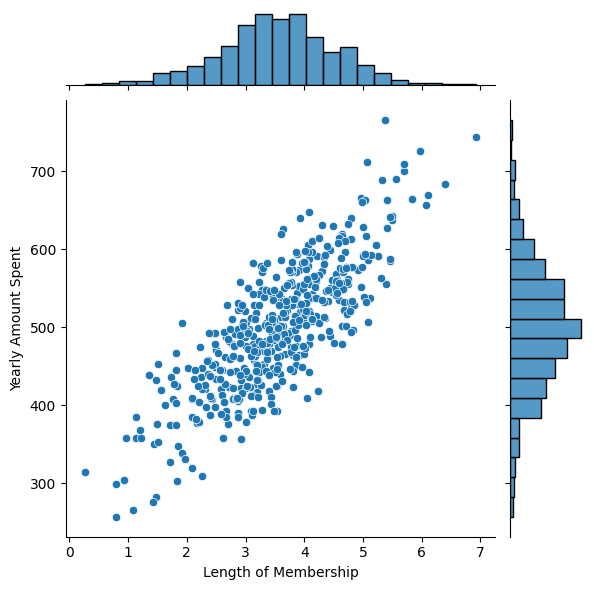

In [9]:
sns.jointplot(data=df, x="Length of Membership", y="Yearly Amount Spent")

**ใช้ [pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html) เพื่อดูความสัมพันธ์ทุกคู่ตัวแปรใน data set**

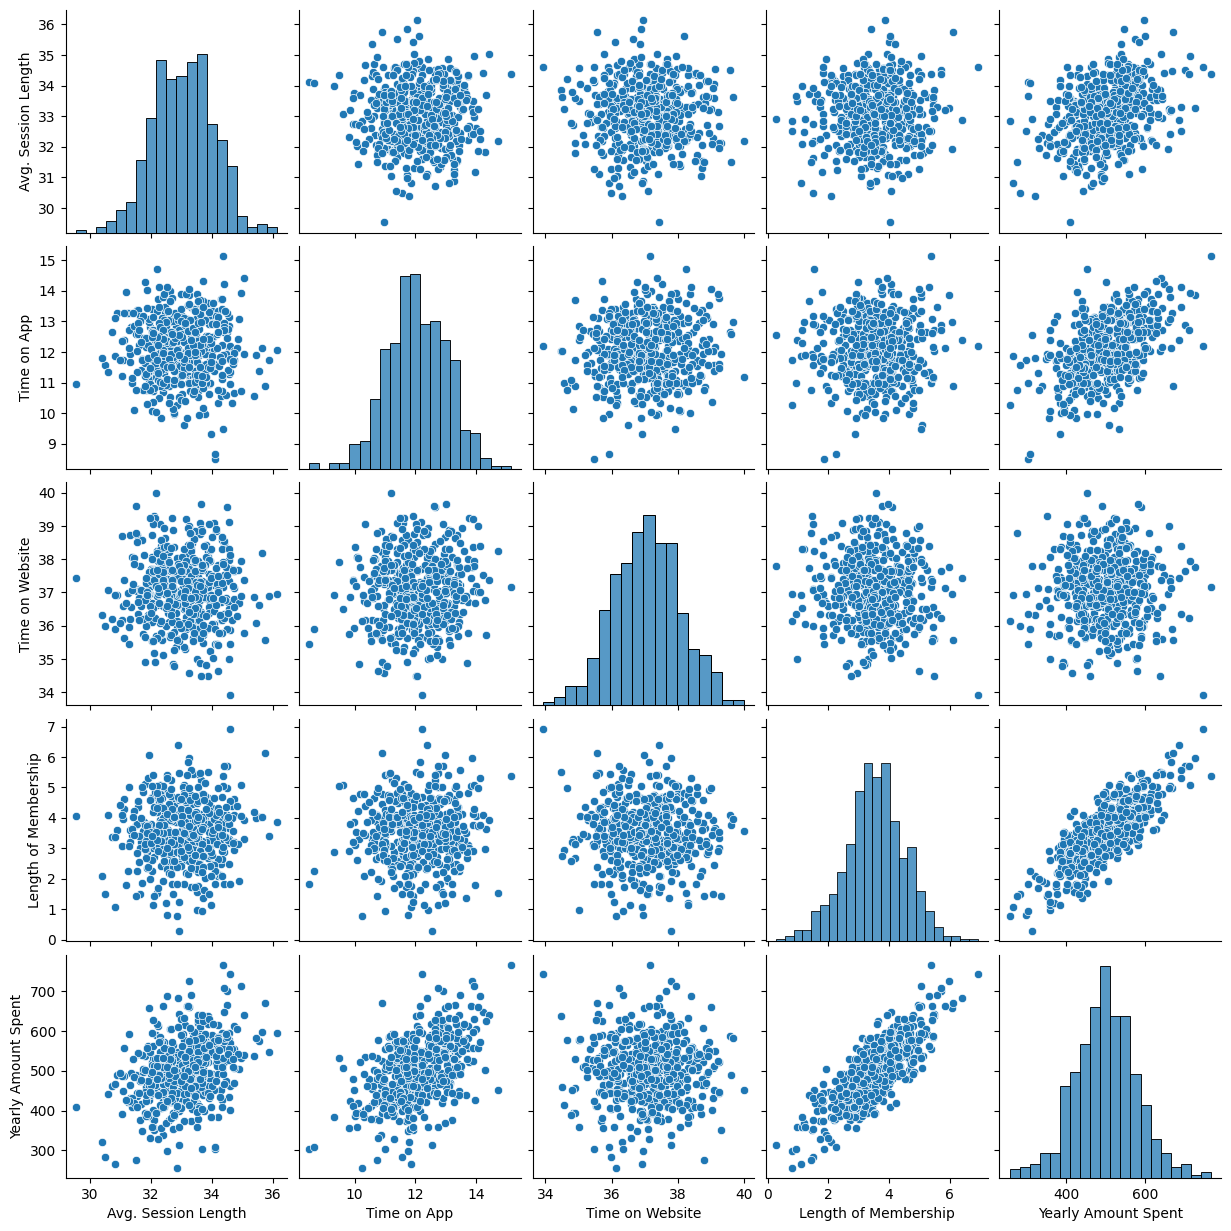

In [10]:
sns.pairplot(df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']])

**จาก pairplot ด้านบน ฟีเจอร์ใดดูมีความสัมพันธ์กับ `Yearly amount spent` มากที่สุด**

**ตรวจสอบค่า Pearson's Correlation**

In [11]:
df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']].corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


## Training and Testing Data

<!-- Now that we've explored the data a bit, let's go ahead and split the data into training and testing sets.   -->
<!-- **Set a variable X equal to the numerical features of the customers and a variable y equal to the "Yearly Amount Spent" column.**   -->


เตรียมข้อมูลสำหรับ Linear Regression โดยให้  
- **`X` (ใช้ตัวพิมพ์ใหญ่เพื่อสื่อความหมายว่าเป็น Matrix) เป็นตัวแปรต้น  
`['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']`**

- **`y` (ใช้ตัวพิมพ์เล็กเพื่อสื่อความหมายว่าเป็น Vector) เป็นตัวแปรตาม `Yearly Amount Spent`**

In [12]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

In [13]:
y = df['Yearly Amount Spent']

In [14]:
y

0      587.951054
1      392.204933
2      487.547505
3      581.852344
4      599.406092
          ...    
495    573.847438
496    529.049004
497    551.620145
498    456.469510
499    497.778642
Name: Yearly Amount Spent, Length: 500, dtype: float64

In [15]:
X=df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y=df['Yearly Amount Spent']

<!-- **Use model_selection.train_test_split from sklearn to split the data into training and testing sets. Set test_size=0.3 and random_state=101** -->

**แบ่งข้อมูลเป็น 2 ชุดคือ Training Data กับ Testing Data โดยใช้คำสั่ง `train_test_split` โดยให้ `test_size=0.3` และ `random_state=101`**

In [16]:
from sklearn.model_selection import train_test_split
# Code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [17]:
X_train.shape

(350, 4)

In [18]:
X_test.shape

(150, 4)

## Training the Model

In [19]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

#### Note!
[`sklearn.linear_model.LinearRegression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) uses "Ordinary least squares".

If you want to create a linear regression model using 'Gradient Descent' you need [`sklearn.linear_model.SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html).

In [20]:
lm.fit(X_train, y_train)

LinearRegression()

**ตรวจสอบ coefficients ของโมเดล**

In [21]:
lm.coef_

array([25.98154972, 38.59015875,  0.19040528, 61.27909654])

In [22]:
lm.intercept_

np.float64(-1047.9327822502382)

In [23]:
pd.DataFrame(lm.coef_, index=X.columns, columns=['Coeff'])

,Coeff
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


## Predicting Test Data
ใช้โมเดลที่เราได้มาพยากรณ์ (predict) ผลลัพธ์

In [24]:
x0 = X.iloc[0]
x0 = np.array(x0).reshape(1,4)
x0

array([[34.49726773, 12.65565115, 39.57766802,  4.08262063]])

In [25]:
y0_pred = -1047.9327822502391 + (25.98154972 * 34.49726773) + (38.59015875 * 12.65565115) + (0.19040528 * 39.57766802) + (61.27909654 * 4.08262063)
y0_pred

594.4583821270883

In [26]:
y0_pred = lm.predict(x0)
y0_pred

/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([594.45838223])

In [27]:
y_pred = lm.predict(X_test)
y_pred

array([456.44186104, 402.72005312, 409.2531539 , 591.4310343 ,
       590.01437275, 548.82396607, 577.59737969, 715.44428115,
       473.7893446 , 545.9211364 , 337.8580314 , 500.38506697,
       552.93478041, 409.6038964 , 765.52590754, 545.83973731,
       693.25969124, 507.32416226, 573.10533175, 573.2076631 ,
       397.44989709, 555.0985107 , 458.19868141, 482.66899911,
       559.2655959 , 413.00946082, 532.25727408, 377.65464817,
       535.0209653 , 447.80070905, 595.54339577, 667.14347072,
       511.96042791, 573.30433971, 505.02260887, 565.30254655,
       460.38785393, 449.74727868, 422.87193429, 456.55615271,
       598.10493696, 449.64517443, 615.34948995, 511.88078685,
       504.37568058, 515.95249276, 568.64597718, 551.61444684,
       356.5552241 , 464.9759817 , 481.66007708, 534.2220025 ,
       256.28674001, 505.30810714, 520.01844434, 315.0298707 ,
       501.98080155, 387.03842642, 472.97419543, 432.8704675 ,
       539.79082198, 590.03070739, 752.86997652, 558.27

**วาด scatterplot เพื่อเปรียบเทียบ y_test และ y_pred**

Text(0, 0.5, 'y_pred')

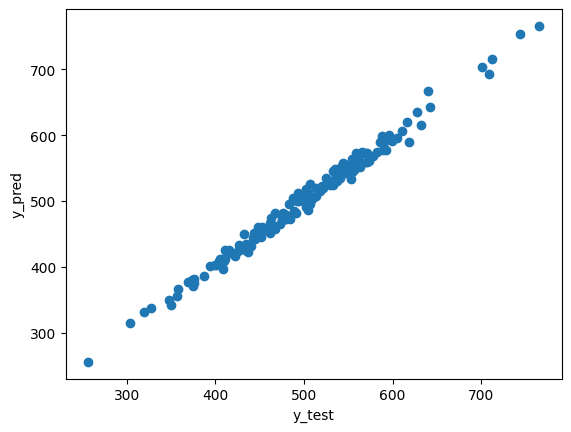

In [28]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')


## Evaluating the Model
ประเมินความถูกต้องของโมเดล

**คำนวณค่า**
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Square Error: {mse}')
print(f'Root Mean Square Error : {rmse}')

Mean Absolute Error: 7.228148653430817
Mean Square Error: 79.81305165097417
Root Mean Square Error : 8.93381506697862


In [30]:
y.describe()

count    500.000000
mean     499.314038
std       79.314782
min      256.670582
25%      445.038277
50%      498.887875
75%      549.313828
max      765.518462
Name: Yearly Amount Spent, dtype: float64

In [31]:
r2_score(y_test, y_pred)

0.9890046246741234

Compare our model with a baseline model **(mean)**

<img src="https://miro.medium.com/max/1376/1*G1Y_-X14q2xMVHlUuaUUdA.png">

**Sample Variance**

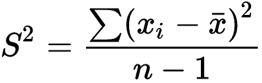

In [32]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy="mean")
dm = dummy.fit(X_train, y_train)
y_pred = dm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2_score(y_test, y_pred)

-0.0005345072603957224

In [33]:
print(f'Mean Absolute Error: {mae}')
print(f'Mean Square Error: {mse}')
print(f'Root Mean Square Error : {rmse}')

Mean Absolute Error: 66.63418052230476
Mean Square Error: 7262.66361445828
Root Mean Square Error : 85.22126268988438


## Residuals

In [34]:
res = y_test - y_pred
res.describe()

count    150.000000
mean       1.969739
std       85.483919
min     -242.052534
25%      -53.853548
50%        5.701289
75%       55.007975
max      266.795345
Name: Yearly Amount Spent, dtype: float64

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

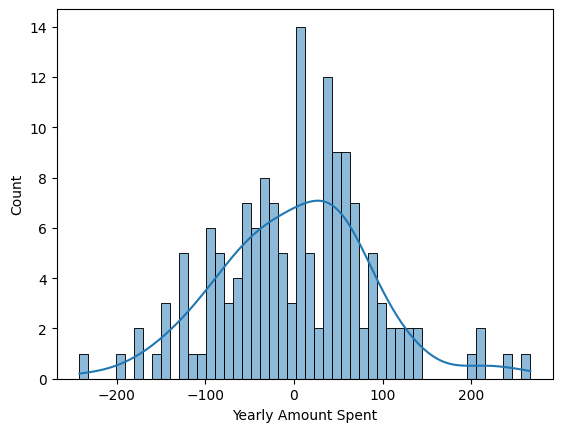

In [35]:
sns.histplot(res, bins=50, kde=True)

## Conclusion

In [36]:
pd.DataFrame(lm.coef_, X.columns, columns=['Coeff'])

,Coeff
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


**Coefficients ด้านบนมีความหมายว่าอย่างไร**

*Answer here*

**คุณคิดว่าทางบริษัทควรลงทุนกับการพัฒนา แอปมือถือ หรือ เว็บไซต์ดี?**

In [37]:
df['Time on Website'].describe()

count    500.000000
mean      37.060445
std        1.010489
min       33.913847
25%       36.349257
50%       37.069367
75%       37.716432
max       40.005182
Name: Time on Website, dtype: float64

In [38]:
df['Time on App'].describe()

count    500.000000
mean      12.052488
std        0.994216
min        8.508152
25%       11.388153
50%       11.983231
75%       12.753850
max       15.126994
Name: Time on App, dtype: float64

*Answer here*

## Great Job!

Congrats on your contract work! The company loved the insights! Let's move on.